# Libreta para corroboracion de resultados del modelo de Segemtnacion de tumores

## Importaciones

In [20]:
import os
from glob import glob

import torch
import numpy as np
import matplotlib.pyplot as plt

from RADSUNet3D import RadsUNet3D

from monai.data import Dataset, DataLoader
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric
from monai.transforms import (
    Compose,
    LoadImaged,
    ToTensord,
    EnsureChannelFirstd,
    #Spacingd
    NormalizeIntensityd,
    CropForegroundd,
    #Resized,
    ConvertToMultiChannelBasedOnBratsClassesd,
    RandRotate90d,
    RandFlipd,
    RandGaussianNoised,
    #RandSpatialCropd,
    RandCropByPosNegLabeld, 
    SpatialPadd
)


## Funcion para definir los diccionarios con las imagenes de entrenamiento y validacion

In [21]:
def definir_rutas_diccionarios():
    data = os.getcwd()
    data = os.path.dirname(data)
    data_split = os.path.join(data,'data_split')
    os.makedirs(data_split, exist_ok=True)
    data = os.path.join(data, 'data')
    data_split_train = os.path.join(data_split, 'train')
    data_split_val = os.path.join(data_split, 'val')

    mask_train = os.path.join(data_split_train,'masks')
    mask_val = os.path.join(data_split_val,'masks')
    images_train = os.path.join(data_split_train,'images')
    images_val = os.path.join(data_split_val,'images')

    flair_train = sorted(glob(os.path.join(images_train, '*_flair.nii.gz')))
    t1ce_train  = sorted(glob(os.path.join(images_train, '*_t1ce.nii.gz')))
    t1_train    = sorted(glob(os.path.join(images_train, '*_t1.nii.gz')))
    t2_train    = sorted(glob(os.path.join(images_train, '*_t2.nii.gz')))
    seg_train   = sorted(glob(os.path.join(mask_train,   '*_seg.nii.gz')))

    train_files = [
        {'image': [f, c, o, d], 'label': s}
        for f, c, o, d, s in zip(flair_train, t1ce_train, t1_train, t2_train, seg_train)
    ]

    flair_val = sorted(glob(os.path.join(images_val, '*_flair.nii.gz')))
    t1ce_val  = sorted(glob(os.path.join(images_val, '*_t1ce.nii.gz')))
    t1_val    = sorted(glob(os.path.join(images_val, '*_t1.nii.gz')))
    t2_val    = sorted(glob(os.path.join(images_val, '*_t2.nii.gz')))
    seg_val   = sorted(glob(os.path.join(mask_val,   '*_seg.nii.gz')))

    val_files = [
        {'image': [f, c, o, d], 'label': s}
        for f, c, o, d, s in zip(flair_val, t1ce_val, t1_val, t2_val, seg_val)
    ]

    print('train:', len(train_files), ' val:', len(val_files))
    if len(train_files)==0 or len(val_files)==0:
        print("Ruta equivocada!")
        raise RuntimeError("No ahy archivos")

    return train_files, val_files

## Se definen que preprocesamiento llevaran las imagenes para el entrenamiento del modelo

In [22]:
def transformaciones():
    train_transforms = Compose(
        [
            LoadImaged(keys=['image', 'label']),
            EnsureChannelFirstd(keys='image'),
            ConvertToMultiChannelBasedOnBratsClassesd(keys='label'),
            #Spacingd(keys=['image', 'label'], pixdim=(1,1,1)),
            NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
            CropForegroundd(keys=['image', 'label'], source_key='image'),
            #Resized(keys=['image', 'label'], spatial_size=[128,128,128], mode=('trilinear', 'nearest')),
            SpatialPadd(keys=['image', 'label'], spatial_size=[128,128,128]),
            RandCropByPosNegLabeld(keys=['image', 'label'], label_key='label',spatial_size=[128,128,128], pos=1, neg=1, num_samples=1,),
            #RandSpatialCropd(keys=['image', 'label'], roi_size=[128,128,128], random_size=False),
            RandRotate90d(keys=['image', 'label'], prob=0.5, spatial_axes=(0, 1)),
            RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=0),
            RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=1),
            RandFlipd(keys=['image', 'label'], prob=0.5, spatial_axis=2),
            RandGaussianNoised(keys=['image'], prob=0.2, mean=0.0, std=0.1),
            #RandModalityDropoutd(keys=['image'], prob=0.5),
            ToTensord(keys=['image', 'label'])
        ]
    )
    val_transforms = Compose(
        [
            LoadImaged(keys=['image', 'label']),
            EnsureChannelFirstd(keys='image'),
            ConvertToMultiChannelBasedOnBratsClassesd(keys='label'),
            #Spacingd(keys=['image', 'label'], pixdim=(1,1,1), mode=("bilinear", "nearest")),
            NormalizeIntensityd(keys='image', nonzero=True, channel_wise=True),
            CropForegroundd(keys=['image', 'label'], source_key='image'),
            #Resized(keys=['image', 'label'], spatial_size=[128,128,128], mode=('trilinear', 'nearest')),
            ToTensord(keys=['image', 'label'])
        ]
    )

    return train_transforms, val_transforms

## Funcion que retorna los lotes de entrenamiento

In [23]:
def lotes(train_files, val_files, train_transforms, val_transforms):
    train_ds = Dataset(data=train_files, transform=train_transforms)
    train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=4, pin_memory=True)

    val_ds = Dataset(data=val_files, transform=val_transforms)
    val_loader = DataLoader(val_ds, batch_size=1, num_workers=0, pin_memory=True)

    return train_ds, train_loader, val_ds, val_loader

## Funcion para ver la prediccion de un paciente en especifico

In [24]:
def predict_view(model, image, modality='t1ce', plane='sagital', frame='max'):
    device = next(model.parameters()).device

    orden_modalidades = {'flair': 0, 't1ce': 1, 't1': 2, 't2': 3}
    if modality not in orden_modalidades:
        print('Modalidad invalida, usando t1ce por defecto')
    mod = orden_modalidades.get(modality, 1)

    orden_planos = {'sagital': 0, 'coronal': 1, 'axial': 2}
    if plane not in orden_planos:
        print('Plano invalido, usando sagital por defecto')
        plane = 'sagital'
    axis = orden_planos[plane] + 1  # +1 porque la dimension 0 es el canal en tensores [C, H, W, D]
    eje_label = {'sagital': 'X', 'coronal': 'Y', 'axial': 'Z'}[plane]

    img  = image['image']   # [4, H, W, D]
    mask = image['label']   # [3, H, W, D]

    def tomar_corte(tensor, indice):
        idx = [slice(None)] * tensor.ndim
        idx[axis] = indice
        return tensor[tuple(idx)]

    if frame == 'max':
        dims_suma = tuple(d for d in range(mask.ndim) if d != axis)
        volumen_por_corte = torch.sum(mask, dim=dims_suma)  # deja solo la dimension del plano elegido
        frame = int(torch.argmax(volumen_por_corte).item())
        print(f'-> Frame seleccionado automaticamente: {eje_label} = {frame}')

    with torch.no_grad():
        img_batch = img.unsqueeze(0).to(device)  # [1, 4, H, W, D]
        logits = sliding_window_inference(img_batch, (128, 128, 128), 1, model, overlap=0.5)
        predict = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()[0]  # [3, H, W, D]

    predict_slice = tomar_corte(predict, frame)  # [3, dim_a, dim_b]
    mask_slice    = tomar_corte(mask, frame)     # [3, dim_a, dim_b]
    img_slice     = tomar_corte(img, frame)      # [4, dim_a, dim_b]

    tc_predict = predict_slice[0].astype('float32')
    wt_predict = predict_slice[1].astype('float32')
    et_predict = predict_slice[2].astype('float32')

    tc_real = mask_slice[0].cpu().numpy().astype('float32')
    wt_real = mask_slice[1].cpu().numpy().astype('float32')
    et_real = mask_slice[2].cpu().numpy().astype('float32')

    cerebro = img_slice[mod].cpu().numpy().astype('float32')

    tumor_realzado_predict = et_predict
    necrosis_predict = np.clip(tc_predict - et_predict, 0, 1)
    edema_predict    = np.clip(wt_predict - tc_predict, 0, 1)

    tumor_realzado_real = et_real
    necrosis_real = np.clip(tc_real - et_real, 0, 1)
    edema_real    = np.clip(wt_real - tc_real, 0, 1)

    stacked_pred = np.stack((tumor_realzado_predict, edema_predict, necrosis_predict), axis=-1).astype('float32')
    stacked_real = np.stack((tumor_realzado_real,    edema_real,    necrosis_real),    axis=-1).astype('float32')

    alpha_pred = (np.clip(tumor_realzado_predict + edema_predict + necrosis_predict, 0, 1) * 0.45).astype('float32')
    rgba_pred  = np.stack((tumor_realzado_predict, edema_predict, necrosis_predict, alpha_pred), axis=-1).astype('float32')

    alpha_real = (np.clip(tumor_realzado_real + edema_real + necrosis_real, 0, 1) * 0.45).astype('float32')
    rgba_real  = np.stack((tumor_realzado_real, edema_real, necrosis_real, alpha_real), axis=-1).astype('float32')

    fig, axes = plt.subplots(3, 4, figsize=(20, 14))
    fig.suptitle(f'Segmentacion BraTS | Corte {plane.capitalize()} ({eje_label}={frame}) | Modalidad: {modality.upper()}', fontsize=20, fontweight='bold')

    axes[0][0].imshow(edema_predict,          cmap='gray'); axes[0][0].set_title('Prediccion - Edema',              fontsize=14); axes[0][0].axis('off')
    axes[0][1].imshow(necrosis_predict,       cmap='gray'); axes[0][1].set_title('Prediccion - Necrosis',           fontsize=14); axes[0][1].axis('off')
    axes[0][2].imshow(tumor_realzado_predict, cmap='gray'); axes[0][2].set_title('Prediccion - Tumor Realzado (ET)',fontsize=14); axes[0][2].axis('off')
    axes[0][3].imshow(stacked_pred);                        axes[0][3].set_title('Prediccion Apilada (Color)',       fontsize=14, color='darkred');  axes[0][3].axis('off')

    axes[1][0].imshow(edema_real,          cmap='gray'); axes[1][0].set_title('Realidad - Edema',              fontsize=14); axes[1][0].axis('off')
    axes[1][1].imshow(necrosis_real,       cmap='gray'); axes[1][1].set_title('Realidad - Necrosis',           fontsize=14); axes[1][1].axis('off')
    axes[1][2].imshow(tumor_realzado_real, cmap='gray'); axes[1][2].set_title('Realidad - Tumor Realzado (ET)',fontsize=14); axes[1][2].axis('off')
    axes[1][3].imshow(stacked_real);                     axes[1][3].set_title('Realidad Apilada (Color)',       fontsize=14, color='darkblue'); axes[1][3].axis('off')

    axes[2][0].imshow(cerebro, cmap='gray');                                        axes[2][0].set_title('Cerebro Limpio',       fontsize=14); axes[2][0].axis('off')
    axes[2][1].imshow(cerebro, cmap='gray'); axes[2][1].imshow(rgba_pred);          axes[2][1].set_title('Cerebro + Prediccion', fontsize=14, fontweight='bold'); axes[2][1].axis('off')
    axes[2][2].imshow(cerebro, cmap='gray'); axes[2][2].imshow(rgba_real);          axes[2][2].set_title('Cerebro + Realidad',   fontsize=14, fontweight='bold'); axes[2][2].axis('off')

    axes[2][3].axis('off')
    axes[2][3].text(0.1, 0.7, 'Leyenda de Segmentos:',         fontsize=16, fontweight='bold')
    axes[2][3].text(0.1, 0.5, 'Tumor Realzado (Rojo)',         color='red',   fontsize=15)
    axes[2][3].text(0.1, 0.3, 'Edema Peritumoral (Verde)',     color='green', fontsize=15)
    axes[2][3].text(0.1, 0.1, 'Necrosis/No Realzado (Azul)',   color='blue',  fontsize=15)

    plt.tight_layout()
    plt.show()
    return predict


### Definir el modelo

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RadsUNet3D(in_channels=4, out_channels=3, features=[32,64,128,256]).to(device)

checkpoint = torch.load('model_brats.pth', map_location=device, weights_only=False)
pesos = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint
model.load_state_dict(pesos)
model.eval()

#Lotes
train_files, val_files = definir_rutas_diccionarios()
train_transforms, val_transforms = transformaciones()
train_ds, train_loader, val_ds, val_loader = lotes(train_files, val_files, train_transforms, val_transforms)

train: 122  val: 41


### VISUALIZAR SEGMENTACION

-> Frame seleccionado automaticamente: Z = 113


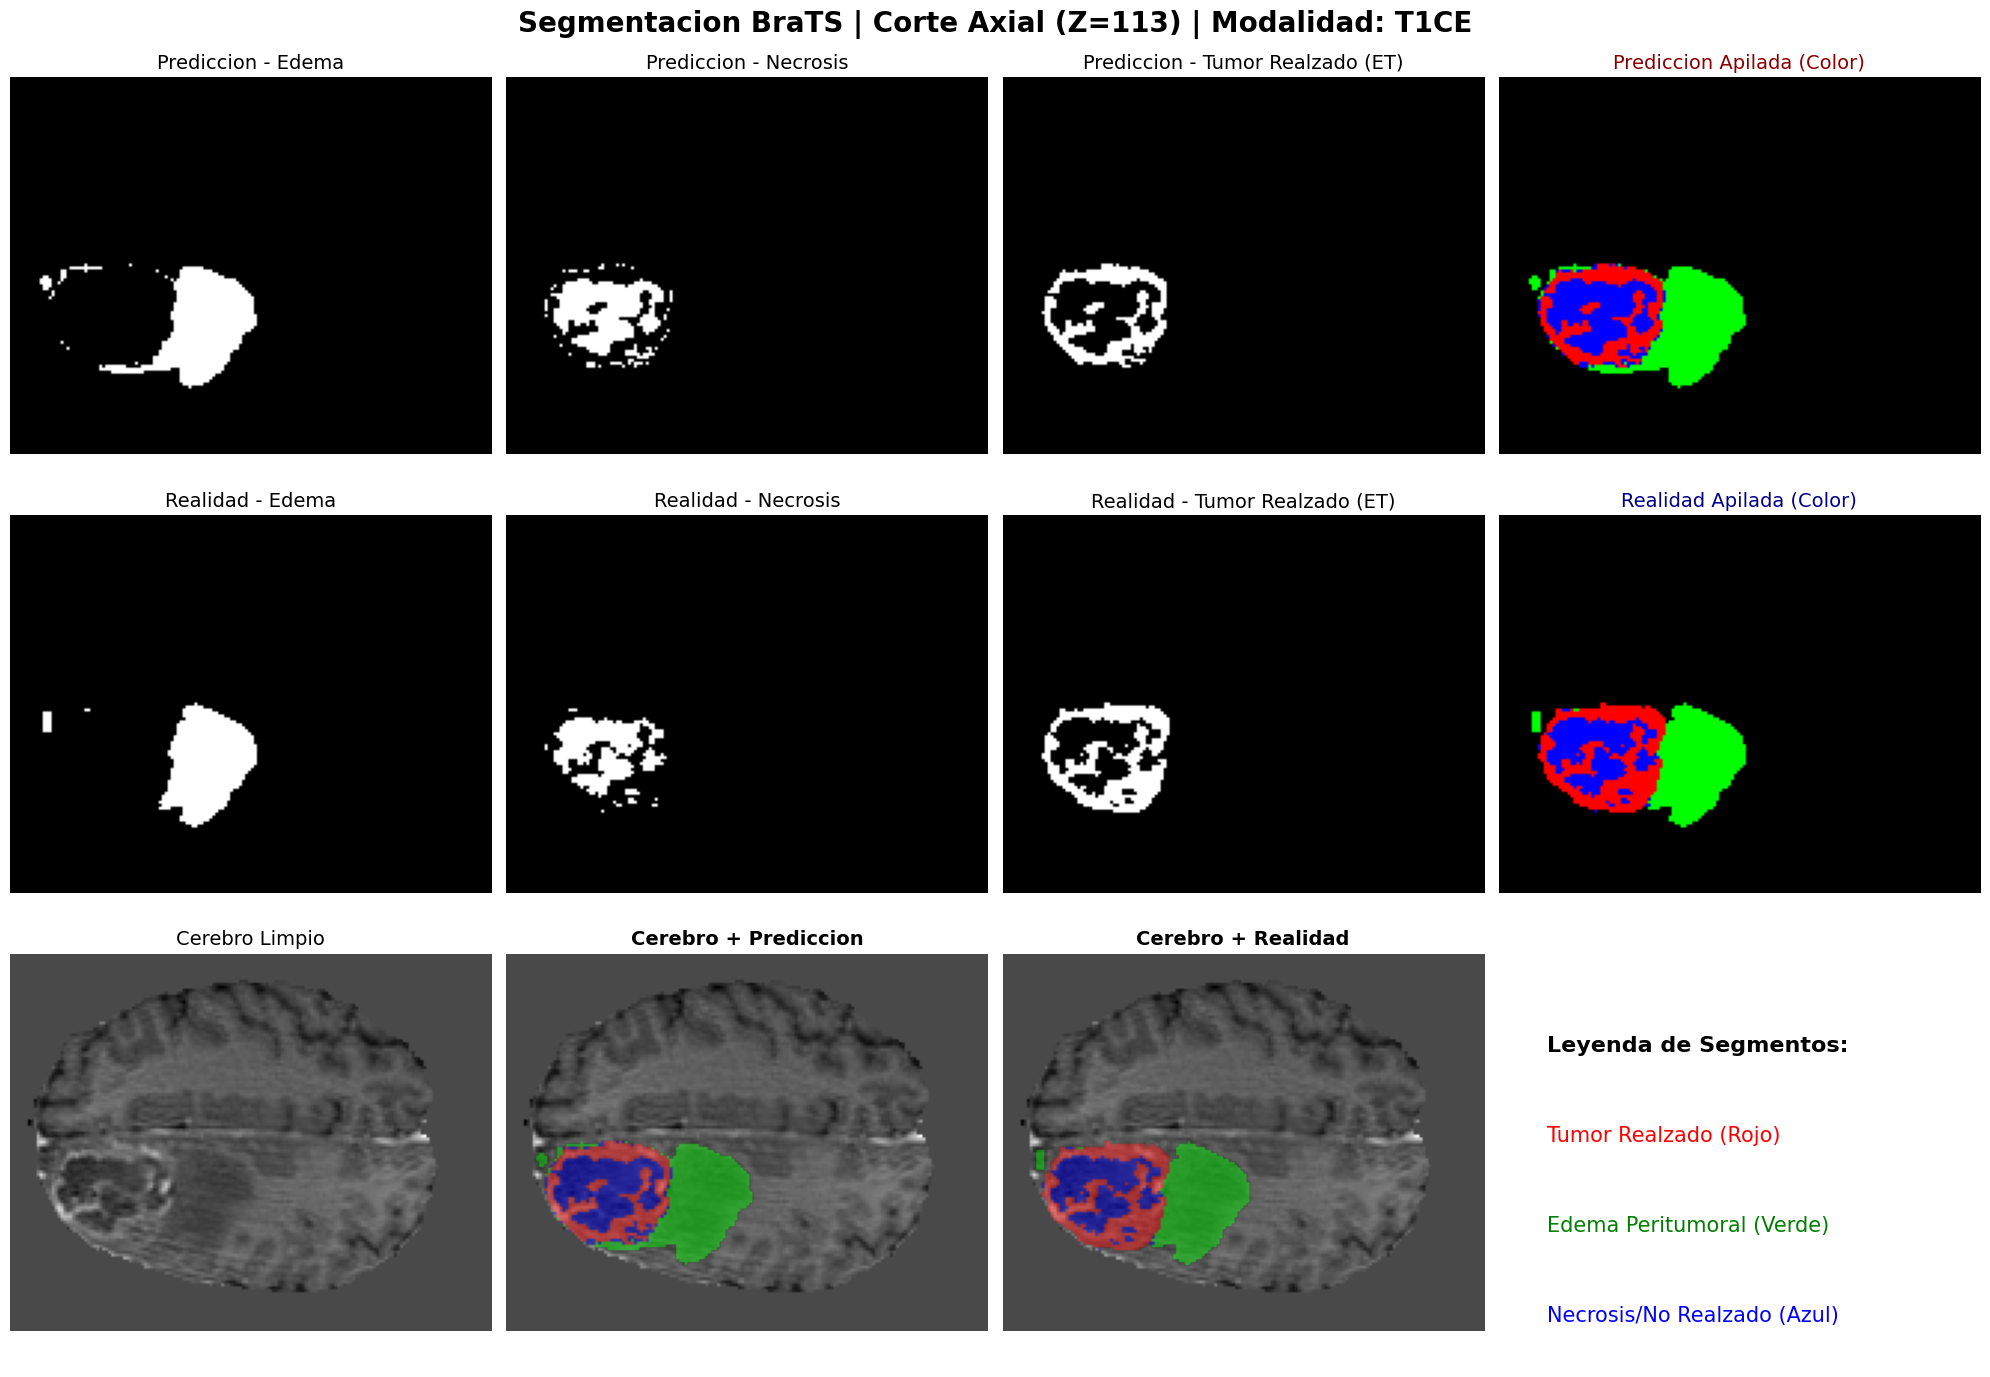

In [26]:
# Cambia el numero (0-40) para elegir el paciente de validacion
predict = predict_view(model, val_ds[9], frame='max', modality='t1ce', plane='axial')

# =============================================================================================================================================

# METRICA DICE-IoU POR CASO 

### Dice score entrenamiento

In [27]:
train_eval_ds     = Dataset(data=train_files, transform=val_transforms)
train_eval_loader = DataLoader(train_eval_ds, batch_size=1, num_workers=0, pin_memory=True)

regiones_tr = ['TC', 'WT', 'ET']
colores_tr  = ['#4C72B0', '#55A868', '#C44E52']

dice_metric_tr = DiceMetric(include_background=True, reduction="none", ignore_empty=True)
dice_lista_tr, volp_lista_tr, volr_lista_tr = [], [], []

model.eval()
with torch.no_grad():
    for i, batch in enumerate(train_eval_loader):
        img   = batch['image'].to(device)
        label = batch['label'].to(device)

        logits = sliding_window_inference(img, (128, 128, 128), 1, model, overlap=0.5)
        pred   = (torch.sigmoid(logits) > 0.5).float()

        d = dice_metric_tr(y_pred=pred, y=label).cpu().numpy().reshape(-1)
        dice_lista_tr.append(d)
        volp_lista_tr.append(pred.sum(dim=(0, 2, 3, 4)).cpu().numpy())
        volr_lista_tr.append(label.sum(dim=(0, 2, 3, 4)).cpu().numpy())

        print(f'Caso {i+1}/{len(train_eval_loader)}  Dice TC={d[0]:.3f} WT={d[1]:.3f} ET={d[2]:.3f}')

dice_por_caso_tr = np.asarray(dice_lista_tr, dtype=float)
vol_pred_tr      = np.asarray(volp_lista_tr, dtype=float)
vol_real_tr      = np.asarray(volr_lista_tr, dtype=float)
dice_metric_tr.reset()

print(f'\nSHAPES: dice={dice_por_caso_tr.shape}, vol_pred={vol_pred_tr.shape}')
print('Todo OK. Ya puedes correr las celdas de gráficas.')


Caso 1/122  Dice TC=0.910 WT=0.944 ET=0.702
Caso 2/122  Dice TC=0.936 WT=0.910 ET=0.898
Caso 3/122  Dice TC=0.961 WT=0.907 ET=0.872
Caso 4/122  Dice TC=0.923 WT=0.857 ET=0.864
Caso 5/122  Dice TC=0.927 WT=0.956 ET=0.904
Caso 6/122  Dice TC=0.892 WT=0.863 ET=0.876
Caso 7/122  Dice TC=0.903 WT=0.905 ET=0.816
Caso 8/122  Dice TC=0.899 WT=0.842 ET=0.875
Caso 9/122  Dice TC=0.931 WT=0.880 ET=0.865
Caso 10/122  Dice TC=0.930 WT=0.911 ET=0.716
Caso 11/122  Dice TC=0.919 WT=0.914 ET=0.852
Caso 12/122  Dice TC=0.808 WT=0.944 ET=0.890
Caso 13/122  Dice TC=0.888 WT=0.921 ET=0.659
Caso 14/122  Dice TC=0.877 WT=0.933 ET=0.869
Caso 15/122  Dice TC=0.864 WT=0.857 ET=0.841
Caso 16/122  Dice TC=0.935 WT=0.908 ET=0.834
Caso 17/122  Dice TC=0.887 WT=0.915 ET=0.754
Caso 18/122  Dice TC=0.950 WT=0.919 ET=0.864
Caso 19/122  Dice TC=0.917 WT=0.902 ET=0.871
Caso 20/122  Dice TC=0.864 WT=0.940 ET=0.774
Caso 21/122  Dice TC=0.856 WT=0.896 ET=0.659
Caso 22/122  Dice TC=0.950 WT=0.936 ET=0.896
Caso 23/122  Dice T

### Dice score validacion

In [ ]:
CALCULAR_HD95 = False 

dice_metric = DiceMetric(include_background=True, reduction="none", ignore_empty=True)
if CALCULAR_HD95:
    from monai.metrics import HausdorffDistanceMetric
    hd95_metric = HausdorffDistanceMetric(include_background=True, percentile=95, reduction="none")

regiones = ['TC', 'WT', 'ET']
colores  = ['#4C72B0', '#55A868', '#C44E52']

dice_lista, hd95_lista, volp_lista, volr_lista = [], [], [], []

model.eval()
with torch.no_grad():
    for i, batch in enumerate(val_loader):
        img   = batch['image'].to(device)
        label = batch['label'].to(device)

        # Inferencia por ventana deslizante (firma posicional: inputs, roi, sw_batch, predictor)
        logits = sliding_window_inference(img, (128, 128, 128), 1, model, overlap=0.5)
        pred = (torch.sigmoid(logits) > 0.5).float()

        d = dice_metric(y_pred=pred, y=label).cpu().numpy().reshape(-1)   # -> [3]
        dice_lista.append(d)
        volp_lista.append(pred.sum(dim=(0, 2, 3, 4)).cpu().numpy())       # -> [3]
        volr_lista.append(label.sum(dim=(0, 2, 3, 4)).cpu().numpy())      # -> [3]

        if CALCULAR_HD95:
            h = hd95_metric(y_pred=pred, y=label).cpu().numpy().reshape(-1)
            hd95_lista.append(h)

        print(f'Caso {i+1}/{len(val_loader)}  Dice TC={d[0]:.3f} WT={d[1]:.3f} ET={d[2]:.3f}')

# --- CONVERSIÓN A NUMPY (este es el paso que antes no se ejecutaba) ---
dice_por_caso = np.asarray(dice_lista, dtype=float)   # forma [N, 3]
vol_pred      = np.asarray(volp_lista, dtype=float)
vol_real      = np.asarray(volr_lista, dtype=float)
hd95_por_caso = np.asarray(hd95_lista, dtype=float) if CALCULAR_HD95 else None
if hd95_por_caso is not None:
    hd95_por_caso[np.isinf(hd95_por_caso)] = np.nan

dice_metric.reset()

# --- VERIFICACIÓN: confirma que NO quedaron vacíos ---
print('\nSHAPES (deben ser del tipo (N, 3)):')
print('  dice_por_caso:', dice_por_caso.shape)
print('  vol_pred:', vol_pred.shape, ' vol_real:', vol_real.shape)
assert dice_por_caso.ndim == 2 and dice_por_caso.shape[1] == 3, \
    'dice_por_caso NO quedó como [N,3]. El bucle no recorrió val_loader; revisa el error de arriba.'
print('\nTodo OK. Ya puedes correr las celdas de gráficas.')

Caso 1/41  Dice TC=0.920 WT=0.929 ET=0.779
Caso 2/41  Dice TC=0.801 WT=0.689 ET=0.713
Caso 3/41  Dice TC=0.933 WT=0.936 ET=0.834
Caso 4/41  Dice TC=0.933 WT=0.909 ET=0.903
Caso 5/41  Dice TC=0.918 WT=0.893 ET=0.785
Caso 6/41  Dice TC=0.911 WT=0.781 ET=0.792
Caso 7/41  Dice TC=0.945 WT=0.949 ET=0.879
Caso 8/41  Dice TC=0.963 WT=0.918 ET=0.904
Caso 9/41  Dice TC=0.929 WT=0.758 ET=0.842
Caso 10/41  Dice TC=0.945 WT=0.944 ET=0.851
Caso 11/41  Dice TC=0.872 WT=0.912 ET=0.789
Caso 12/41  Dice TC=0.931 WT=0.908 ET=0.884
Caso 13/41  Dice TC=0.883 WT=0.855 ET=0.609
Caso 14/41  Dice TC=0.724 WT=0.801 ET=0.769
Caso 15/41  Dice TC=0.950 WT=0.902 ET=0.871
Caso 16/41  Dice TC=0.948 WT=0.924 ET=0.889
Caso 17/41  Dice TC=0.945 WT=0.939 ET=0.869
Caso 18/41  Dice TC=0.921 WT=0.878 ET=0.861
Caso 19/41  Dice TC=0.608 WT=0.778 ET=0.603
Caso 20/41  Dice TC=0.933 WT=0.928 ET=0.822
Caso 21/41  Dice TC=0.940 WT=0.798 ET=0.848
Caso 22/41  Dice TC=0.831 WT=0.886 ET=0.769
Caso 23/41  Dice TC=0.866 WT=0.914 ET=0.8

### IoU score entrenamiento

In [29]:
train_eval_ds_iou     = Dataset(data=train_files, transform=val_transforms)
train_eval_loader_iou = DataLoader(train_eval_ds_iou, batch_size=1, num_workers=0, pin_memory=True)

iou_lista_tr, volp_lista_iou_tr, volr_lista_iou_tr = [], [], []

model.eval()
with torch.no_grad():
    for i, batch in enumerate(train_eval_loader_iou):
        img   = batch['image'].to(device)
        label = batch['label'].to(device)

        logits = sliding_window_inference(img, (128, 128, 128), 1, model, overlap=0.5)
        pred   = (torch.sigmoid(logits) > 0.5).float()

        inter = (pred * label).sum(dim=(2, 3, 4))
        union = (pred + label - pred * label).sum(dim=(2, 3, 4))
        iou   = torch.where(union > 0, inter / union,
                            torch.full_like(inter, float('nan')))
        iou_np = iou.cpu().numpy().reshape(-1)

        iou_lista_tr.append(iou_np)
        volp_lista_iou_tr.append(pred.sum(dim=(0, 2, 3, 4)).cpu().numpy())
        volr_lista_iou_tr.append(label.sum(dim=(0, 2, 3, 4)).cpu().numpy())

        print(f'Caso {i+1}/{len(train_eval_loader_iou)}  IoU TC={iou_np[0]:.3f} WT={iou_np[1]:.3f} ET={iou_np[2]:.3f}')

iou_por_caso_tr   = np.asarray(iou_lista_tr,      dtype=float)
vol_pred_iou_tr   = np.asarray(volp_lista_iou_tr,  dtype=float)
vol_real_iou_tr   = np.asarray(volr_lista_iou_tr,  dtype=float)

print(f'\nSHAPES: iou={iou_por_caso_tr.shape}')
print('Todo OK.')


Caso 1/122  IoU TC=0.835 WT=0.895 ET=0.540
Caso 2/122  IoU TC=0.879 WT=0.835 ET=0.815
Caso 3/122  IoU TC=0.925 WT=0.830 ET=0.773
Caso 4/122  IoU TC=0.857 WT=0.750 ET=0.761
Caso 5/122  IoU TC=0.863 WT=0.915 ET=0.825
Caso 6/122  IoU TC=0.805 WT=0.759 ET=0.780
Caso 7/122  IoU TC=0.824 WT=0.826 ET=0.690
Caso 8/122  IoU TC=0.816 WT=0.728 ET=0.778
Caso 9/122  IoU TC=0.871 WT=0.785 ET=0.762
Caso 10/122  IoU TC=0.870 WT=0.837 ET=0.558
Caso 11/122  IoU TC=0.850 WT=0.841 ET=0.742
Caso 12/122  IoU TC=0.678 WT=0.895 ET=0.802
Caso 13/122  IoU TC=0.798 WT=0.854 ET=0.492
Caso 14/122  IoU TC=0.780 WT=0.874 ET=0.768
Caso 15/122  IoU TC=0.761 WT=0.750 ET=0.726
Caso 16/122  IoU TC=0.879 WT=0.831 ET=0.715
Caso 17/122  IoU TC=0.797 WT=0.844 ET=0.605
Caso 18/122  IoU TC=0.905 WT=0.851 ET=0.761
Caso 19/122  IoU TC=0.847 WT=0.822 ET=0.772
Caso 20/122  IoU TC=0.760 WT=0.887 ET=0.631
Caso 21/122  IoU TC=0.749 WT=0.812 ET=0.491
Caso 22/122  IoU TC=0.904 WT=0.880 ET=0.812
Caso 23/122  IoU TC=0.738 WT=0.768 ET=0.7

### IoU score validacion

In [30]:
regiones_iou = ['TC', 'WT', 'ET']
colores_iou  = ['#4C72B0', '#55A868', '#C44E52']

iou_lista_val, volp_lista_iou_val, volr_lista_iou_val = [], [], []

model.eval()
with torch.no_grad():
    for i, batch in enumerate(val_loader):
        img   = batch['image'].to(device)
        label = batch['label'].to(device)

        logits = sliding_window_inference(img, (128, 128, 128), 1, model, overlap=0.5)
        pred   = (torch.sigmoid(logits) > 0.5).float()

        inter = (pred * label).sum(dim=(2, 3, 4))                   # [1, 3]
        union = (pred + label - pred * label).sum(dim=(2, 3, 4))    # [1, 3]
        iou   = torch.where(union > 0, inter / union,
                            torch.full_like(inter, float('nan')))
        iou_np = iou.cpu().numpy().reshape(-1)                       # [3]

        iou_lista_val.append(iou_np)
        volp_lista_iou_val.append(pred.sum(dim=(0, 2, 3, 4)).cpu().numpy())
        volr_lista_iou_val.append(label.sum(dim=(0, 2, 3, 4)).cpu().numpy())

        print(f'Caso {i+1}/{len(val_loader)}  IoU TC={iou_np[0]:.3f} WT={iou_np[1]:.3f} ET={iou_np[2]:.3f}')

iou_por_caso_val   = np.asarray(iou_lista_val,     dtype=float)
vol_pred_iou_val   = np.asarray(volp_lista_iou_val, dtype=float)
vol_real_iou_val   = np.asarray(volr_lista_iou_val, dtype=float)

print(f'\nSHAPES: iou={iou_por_caso_val.shape}')
print('Todo OK.')


Caso 1/41  IoU TC=0.852 WT=0.868 ET=0.638
Caso 2/41  IoU TC=0.668 WT=0.526 ET=0.553
Caso 3/41  IoU TC=0.874 WT=0.880 ET=0.715
Caso 4/41  IoU TC=0.875 WT=0.834 ET=0.822
Caso 5/41  IoU TC=0.849 WT=0.807 ET=0.646
Caso 6/41  IoU TC=0.837 WT=0.640 ET=0.655
Caso 7/41  IoU TC=0.895 WT=0.903 ET=0.783
Caso 8/41  IoU TC=0.928 WT=0.849 ET=0.825
Caso 9/41  IoU TC=0.868 WT=0.610 ET=0.727
Caso 10/41  IoU TC=0.895 WT=0.894 ET=0.741
Caso 11/41  IoU TC=0.773 WT=0.838 ET=0.651
Caso 12/41  IoU TC=0.871 WT=0.831 ET=0.792
Caso 13/41  IoU TC=0.790 WT=0.746 ET=0.437
Caso 14/41  IoU TC=0.567 WT=0.669 ET=0.625
Caso 15/41  IoU TC=0.905 WT=0.822 ET=0.771
Caso 16/41  IoU TC=0.901 WT=0.860 ET=0.801
Caso 17/41  IoU TC=0.896 WT=0.885 ET=0.769
Caso 18/41  IoU TC=0.853 WT=0.783 ET=0.756
Caso 19/41  IoU TC=0.437 WT=0.637 ET=0.432
Caso 20/41  IoU TC=0.874 WT=0.865 ET=0.697
Caso 21/41  IoU TC=0.886 WT=0.664 ET=0.736
Caso 22/41  IoU TC=0.711 WT=0.795 ET=0.625
Caso 23/41  IoU TC=0.764 WT=0.842 ET=0.690
Caso 24/41  IoU TC=0

## Grafico de barras Dice por region en Entrenamiento - Validacion

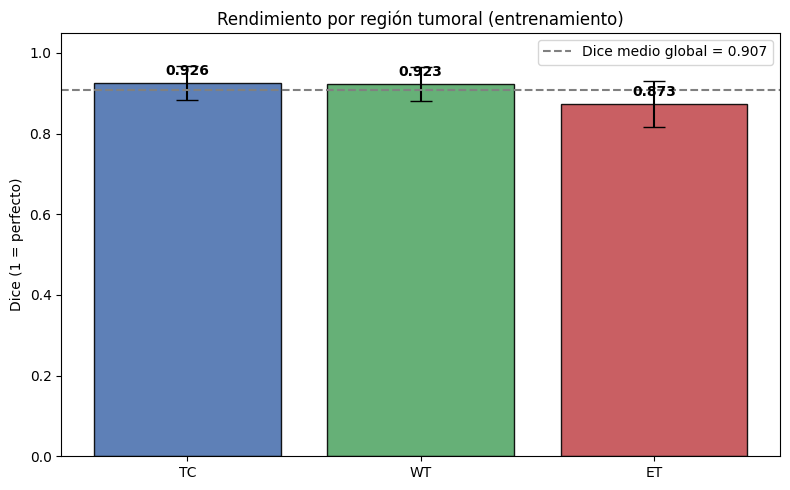

In [31]:
medias_tr      = np.nanmean(dice_por_caso_tr, axis=0)
desv_tr        = np.nanstd(dice_por_caso_tr, axis=0)
global_mean_tr = np.nanmean(medias_tr)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(regiones_tr, medias_tr, yerr=desv_tr, capsize=8,
                color=colores_tr, edgecolor='black', alpha=0.9)
for b, m in zip(barras, medias_tr):
    ax.text(b.get_x() + b.get_width()/2, m + 0.02, f'{m:.3f}', ha='center', fontweight='bold')
ax.axhline(global_mean_tr, ls='--', color='gray',
           label=f'Dice medio global = {global_mean_tr:.3f}')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Dice (1 = perfecto)')
ax.set_title('Rendimiento por región tumoral (entrenamiento)')
ax.legend()
plt.tight_layout()
plt.show()


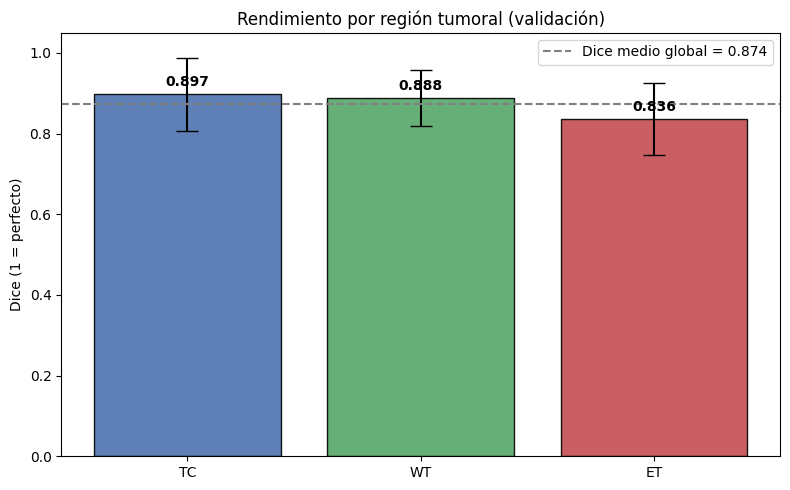

In [32]:
medias = np.nanmean(dice_por_caso, axis=0)
desv   = np.nanstd(dice_por_caso, axis=0)
global_mean = np.nanmean(medias)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(regiones, medias, yerr=desv, capsize=8, color=colores, edgecolor='black', alpha=0.9)
for b, m in zip(barras, medias):
    ax.text(b.get_x() + b.get_width()/2, m + 0.02, f'{m:.3f}', ha='center', fontweight='bold')
ax.axhline(global_mean, ls='--', color='gray', label=f'Dice medio global = {global_mean:.3f}')
ax.set_ylim(0, 1.05); ax.set_ylabel('Dice (1 = perfecto)')
ax.set_title('Rendimiento por región tumoral (validación)'); ax.legend()
plt.tight_layout(); plt.show()

## Grafico de barras IoU por region Entrenamiento - Validacion

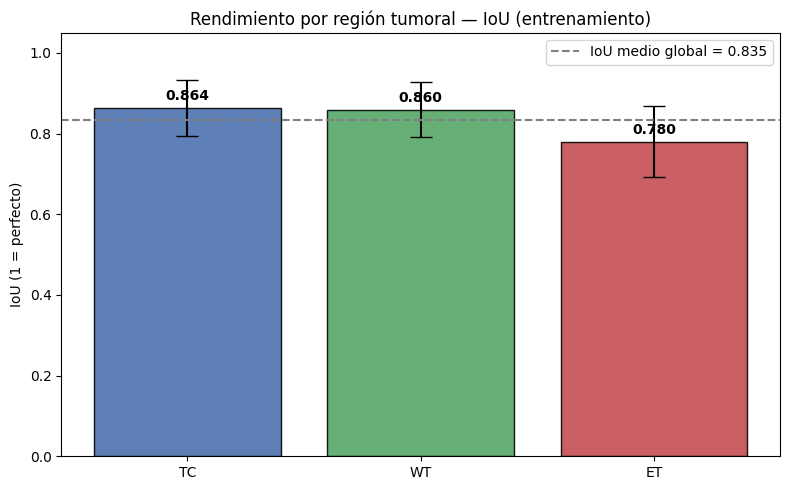

In [33]:
medias_iou_tr      = np.nanmean(iou_por_caso_tr, axis=0)
desv_iou_tr        = np.nanstd(iou_por_caso_tr, axis=0)
global_mean_iou_tr = np.nanmean(medias_iou_tr)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(regiones_iou, medias_iou_tr, yerr=desv_iou_tr, capsize=8,
                color=colores_iou, edgecolor='black', alpha=0.9)
for b, m in zip(barras, medias_iou_tr):
    ax.text(b.get_x() + b.get_width()/2, m + 0.02, f'{m:.3f}', ha='center', fontweight='bold')
ax.axhline(global_mean_iou_tr, ls='--', color='gray',
           label=f'IoU medio global = {global_mean_iou_tr:.3f}')
ax.set_ylim(0, 1.05)
ax.set_ylabel('IoU (1 = perfecto)')
ax.set_title('Rendimiento por región tumoral — IoU (entrenamiento)')
ax.legend()
plt.tight_layout()
plt.show()


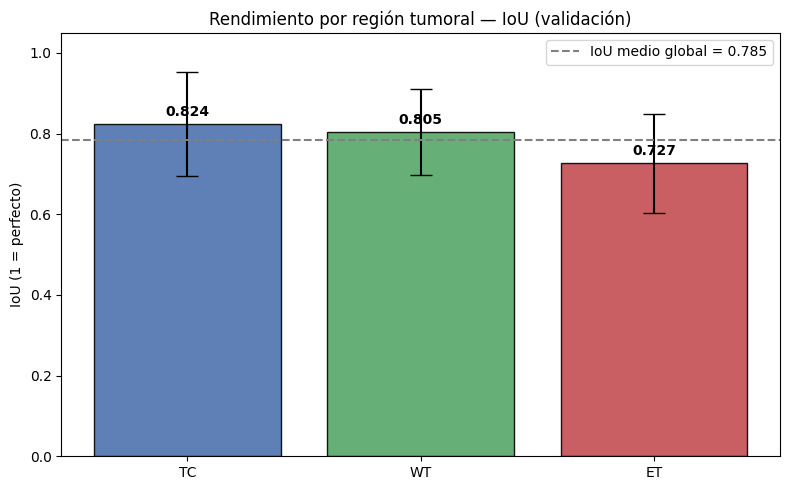

In [34]:
medias_iou_val      = np.nanmean(iou_por_caso_val, axis=0)
desv_iou_val        = np.nanstd(iou_por_caso_val, axis=0)
global_mean_iou_val = np.nanmean(medias_iou_val)

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(regiones_iou, medias_iou_val, yerr=desv_iou_val, capsize=8,
                color=colores_iou, edgecolor='black', alpha=0.9)
for b, m in zip(barras, medias_iou_val):
    ax.text(b.get_x() + b.get_width()/2, m + 0.02, f'{m:.3f}', ha='center', fontweight='bold')
ax.axhline(global_mean_iou_val, ls='--', color='gray',
           label=f'IoU medio global = {global_mean_iou_val:.3f}')
ax.set_ylim(0, 1.05)
ax.set_ylabel('IoU (1 = perfecto)')
ax.set_title('Rendimiento por región tumoral — IoU (validación)')
ax.legend()
plt.tight_layout()
plt.show()


# Distribucion entre casos en Entrenamiento - Validacion

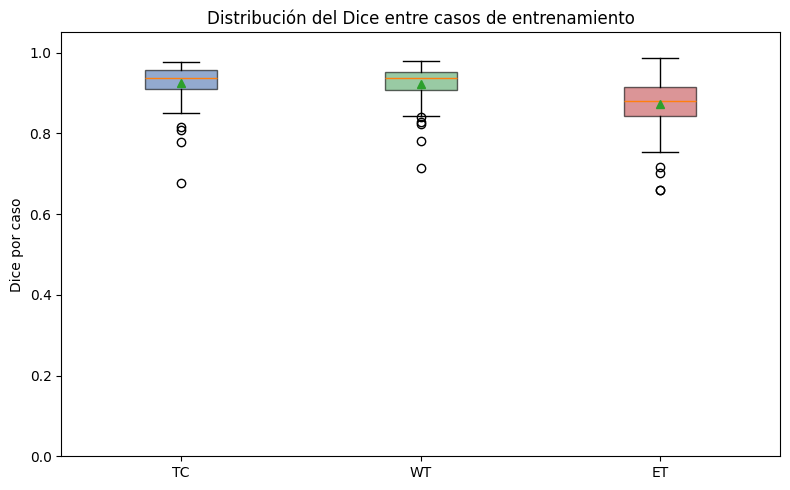

In [35]:
datos_tr = [dice_por_caso_tr[~np.isnan(dice_por_caso_tr[:, j]), j] for j in range(3)]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(datos_tr, patch_artist=True, showmeans=True)
ax.set_xticks(range(1, len(regiones_tr) + 1))
ax.set_xticklabels(regiones_tr)
for parche, c in zip(bp['boxes'], colores_tr):
    parche.set_facecolor(c)
    parche.set_alpha(0.6)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Dice por caso')
ax.set_title('Distribución del Dice entre casos de entrenamiento')
plt.tight_layout()
plt.show()


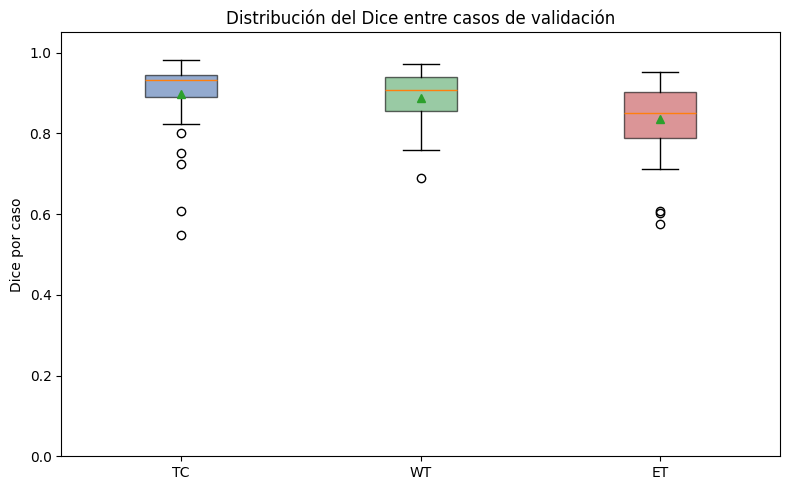

In [36]:
datos = [dice_por_caso[~np.isnan(dice_por_caso[:, j]), j] for j in range(3)]
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(datos, patch_artist=True, showmeans=True)
ax.set_xticks(range(1, len(regiones) + 1))
ax.set_xticklabels(regiones)
for parche, c in zip(bp['boxes'], colores):
    parche.set_facecolor(c); parche.set_alpha(0.6)
ax.set_ylim(0, 1.05); ax.set_ylabel('Dice por caso')
ax.set_title('Distribución del Dice entre casos de validación')
plt.tight_layout(); plt.show()

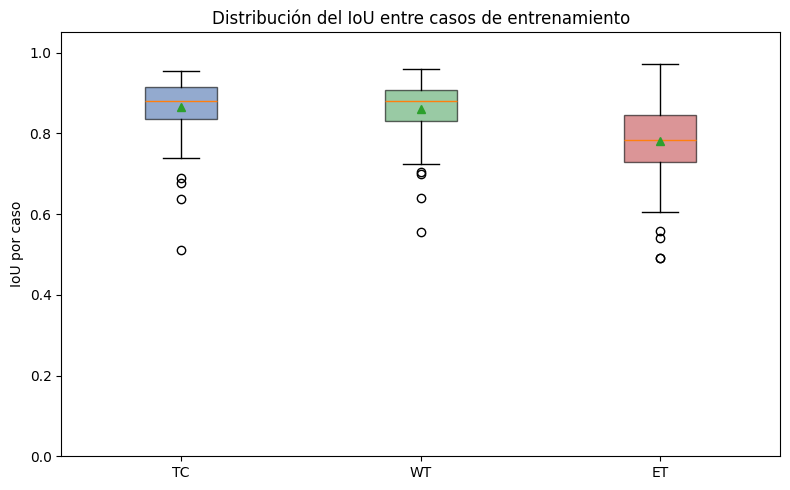

In [37]:
datos_iou_tr = [iou_por_caso_tr[~np.isnan(iou_por_caso_tr[:, j]), j] for j in range(3)]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(datos_iou_tr, patch_artist=True, showmeans=True)
ax.set_xticks(range(1, len(regiones_iou) + 1))
ax.set_xticklabels(regiones_iou)
for parche, c in zip(bp['boxes'], colores_iou):
    parche.set_facecolor(c)
    parche.set_alpha(0.6)
ax.set_ylim(0, 1.05)
ax.set_ylabel('IoU por caso')
ax.set_title('Distribución del IoU entre casos de entrenamiento')
plt.tight_layout()
plt.show()


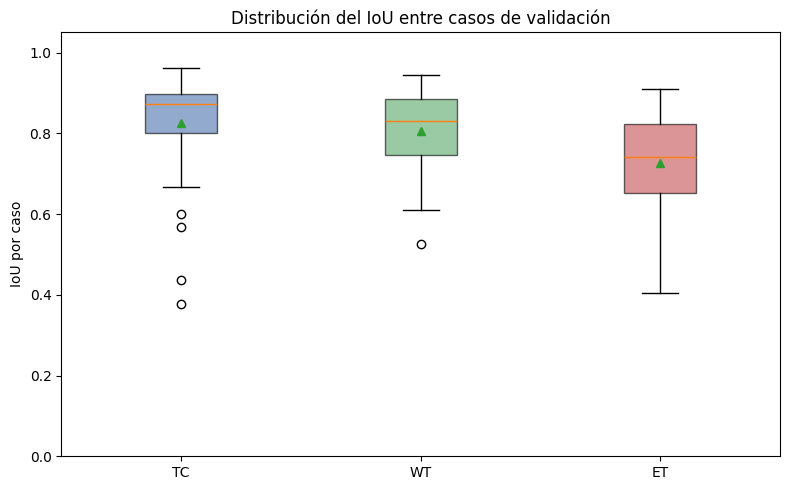

In [38]:
datos_iou_val = [iou_por_caso_val[~np.isnan(iou_por_caso_val[:, j]), j] for j in range(3)]
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(datos_iou_val, patch_artist=True, showmeans=True)
ax.set_xticks(range(1, len(regiones_iou) + 1))
ax.set_xticklabels(regiones_iou)
for parche, c in zip(bp['boxes'], colores_iou):
    parche.set_facecolor(c)
    parche.set_alpha(0.6)
ax.set_ylim(0, 1.05)
ax.set_ylabel('IoU por caso')
ax.set_title('Distribución del IoU entre casos de validación')
plt.tight_layout()
plt.show()


## Volumen Predicho vs Volumen Real Entrenamiento - Validacion

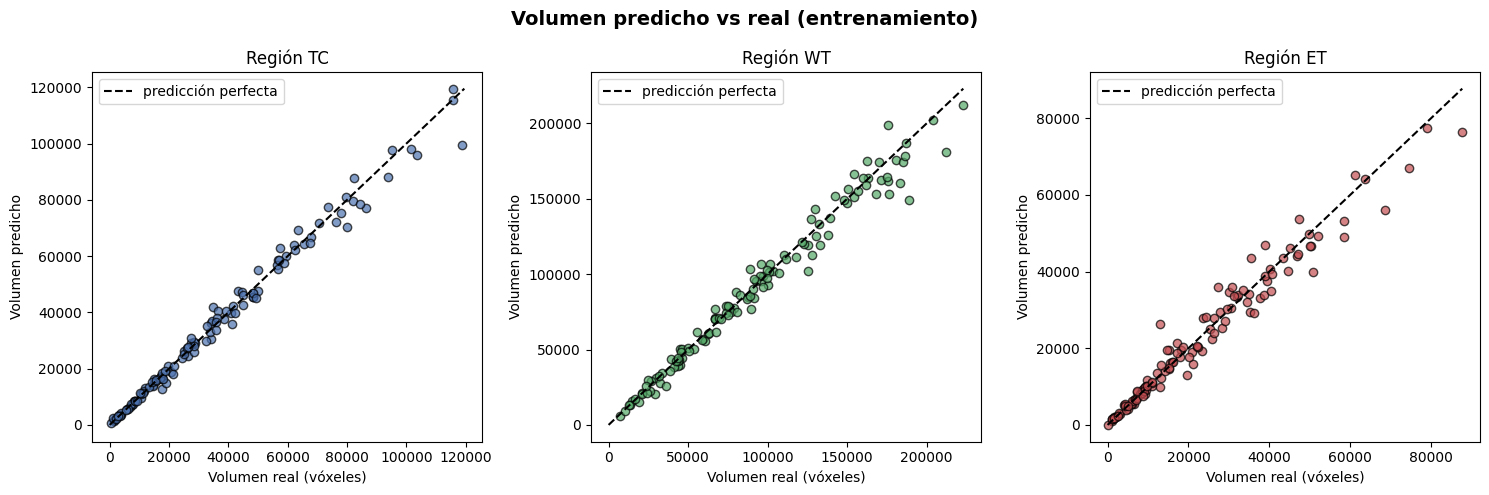

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for j, (ax, r) in enumerate(zip(axs, regiones_tr)):
    x, y = vol_real_tr[:, j], vol_pred_tr[:, j]
    ax.scatter(x, y, alpha=0.7, color=colores_tr[j], edgecolor='black')
    lim = max(x.max(), y.max(), 1)
    ax.plot([0, lim], [0, lim], 'k--', label='predicción perfecta')
    ax.set_xlabel('Volumen real (vóxeles)')
    ax.set_ylabel('Volumen predicho')
    ax.set_title(f'Región {r}')
    ax.legend()
plt.suptitle('Volumen predicho vs real (entrenamiento)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


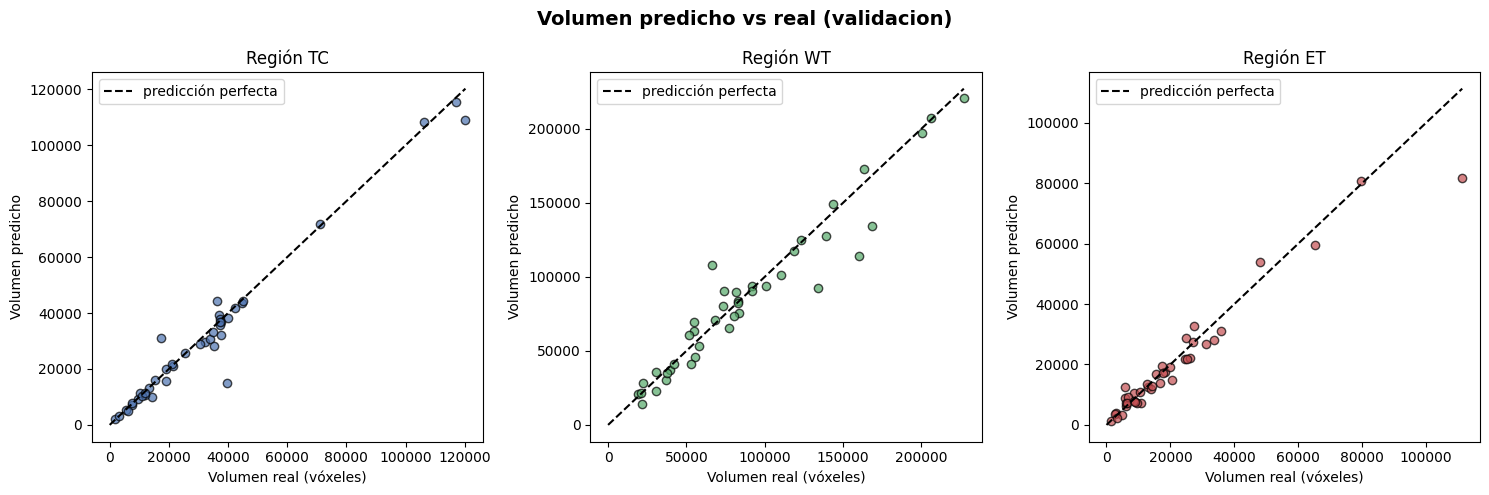

In [40]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for j, (ax, r) in enumerate(zip(axs, regiones)):
    x, y = vol_real[:, j], vol_pred[:, j]
    ax.scatter(x, y, alpha=0.7, color=colores[j], edgecolor='black')
    lim = max(x.max(), y.max(), 1)
    ax.plot([0, lim], [0, lim], 'k--', label='predicción perfecta')
    ax.set_xlabel('Volumen real (vóxeles)'); ax.set_ylabel('Volumen predicho')
    ax.set_title(f'Región {r}'); ax.legend()
plt.suptitle('Volumen predicho vs real (validacion)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()